In [2]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt

In [3]:
def M_Jac_iter(V,V0=1.0):
    Nx , Ny = V.shape
    for i in range(1,Nx-1):
        for j in range(1,Ny-1):
            if V[i,j] != 1:
                V[i,j] = 0.25*(V[i+1,j] + V[i-1,j] + V[i,j+1] + V[i,j-1])
    return V

def V_cuadrado(x,y,L=0.5,V0=1.0):
    Nx , Ny = len(x) , len(y)
    malla = np.zeros((Nx,Ny))
    for i in range(1,Nx-1):
        for j in range(1,Ny-1):
            if  -0.25*L < x[i] < 0.5*L and -0.5*L < y[j] < 0.5*L:
                malla[i,j] = 1
            else:
                malla[i,j] = rd.random()
    return V0*malla

def Met_Jac(V,V0=1,err=1e-3,step=20):
    diferencia = 1
    while diferencia > err:
        for i in range(step):
            V = M_Jac_iter(V,V0=V0)
        V_ref = M_Jac_iter(np.copy(V))
        diferencia = np.max(abs(V_ref-V))
    return V

In [4]:
x , y = np.linspace(-1,2) , np.linspace(-1,1.5)
V = V_cuadrado(x,y)

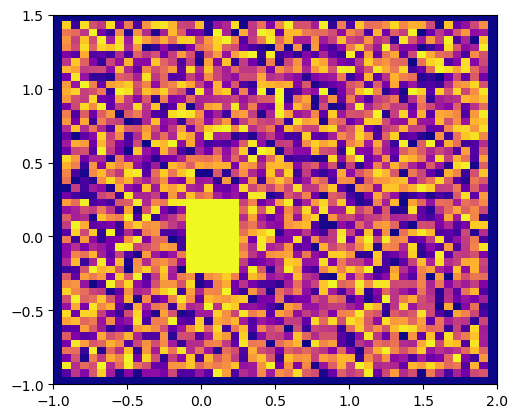

In [5]:
plt.imshow(V.transpose(),
           extent=(x[0],x[-1],y[0],y[-1]),
           origin='lower',
           cmap='plasma')
plt.show()

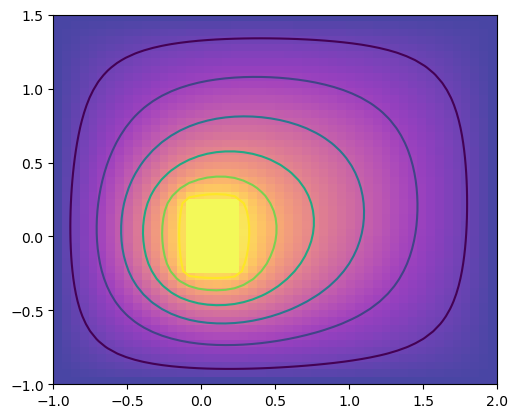

In [6]:
V = Met_Jac(V)
plt.imshow(V.transpose(),
           extent=(x[0],x[-1],y[0],y[-1]),
           origin='lower',
           cmap='plasma',alpha=0.75)
niveles = np.linspace(0.1,0.9,6)
plt.contour(x,y,V.transpose(),levels=niveles)
plt.gca().set_aspect('equal')
plt.show()

In [8]:
A = np.array([[1,2,3],[4,5,6],[7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [9]:
A[0,:], A[:,0]

(array([1, 2, 3]), array([1, 4, 7]))

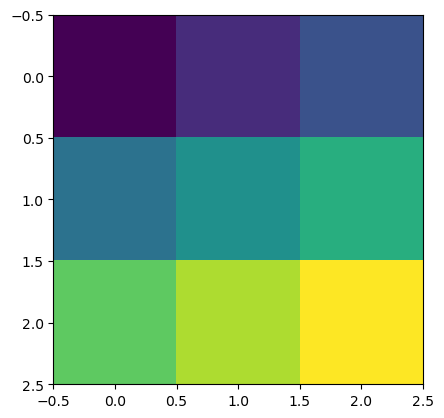

In [10]:
plt.imshow(A)

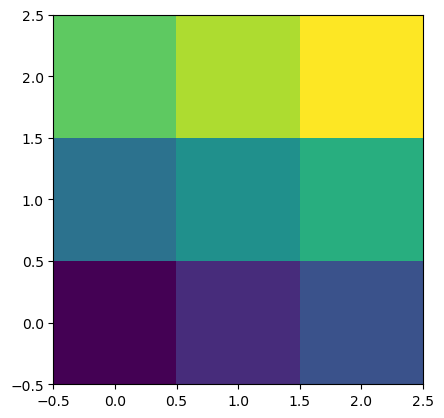

In [11]:
plt.imshow(A,origin='lower')

In [12]:
Ex, Ey = np.gradient(-V.transpose())

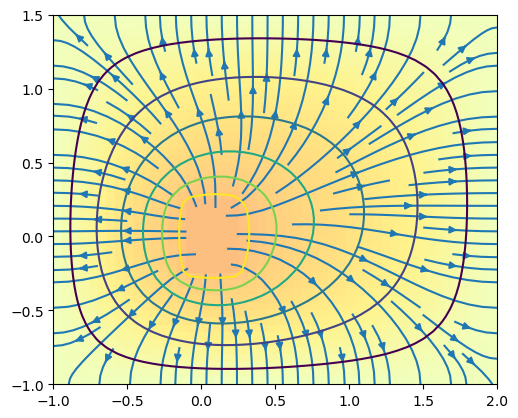

In [13]:
plt.imshow(V.transpose(),
           extent=(x[0],x[-1],y[0],y[-1]),
           origin='lower',
           cmap='Wistia',alpha=0.5)
niveles = np.linspace(0.1,0.9,6)
plt.streamplot(x,y,Ey,Ex)
plt.contour(x,y,V.transpose(),levels=niveles)
plt.gca().set_aspect('equal')
plt.show()

In [14]:
def V_circ(x,y,R=0.5,orig=[0,0],V0=1.0):
    Nx , Ny = len(x) , len(y)
    malla = np.zeros((Nx,Ny))
    for i in range(1,Nx-1):
        for j in range(1,Ny-1):
            if  np.sqrt((x[i]-orig[0])**2 + (y[j]-orig[1])**2 ) < R:
                malla[i,j] = 1
            else:
                malla[i,j] = rd.random()
    return V0*malla

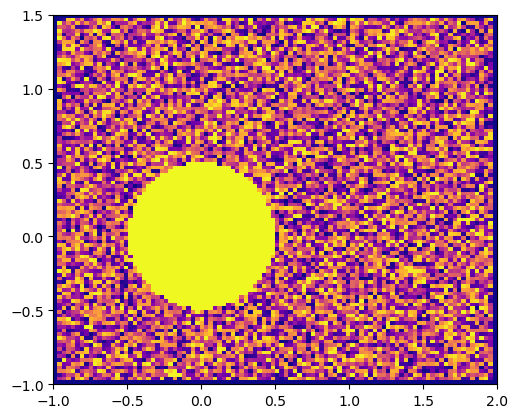

In [15]:
x , y = np.linspace(-1,2,100) , np.linspace(-1,1.5,100)
V = V_circ(x,y)
plt.imshow(V.transpose(),
           extent=(x[0],x[-1],y[0],y[-1]),
           origin='lower',
           cmap='plasma')
plt.show()

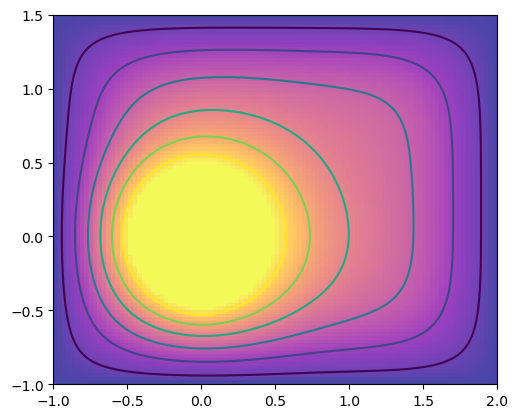

In [16]:
V = Met_Jac(V)
plt.imshow(V.transpose(),
           extent=(x[0],x[-1],y[0],y[-1]),
           origin='lower',
           cmap='plasma',alpha=0.75)
niveles = np.linspace(0.1,0.9,6)
plt.contour(x,y,V.transpose(),levels=niveles)
plt.gca().set_aspect('equal')
plt.show()

In [17]:
Ex, Ey = np.gradient(-V.transpose())

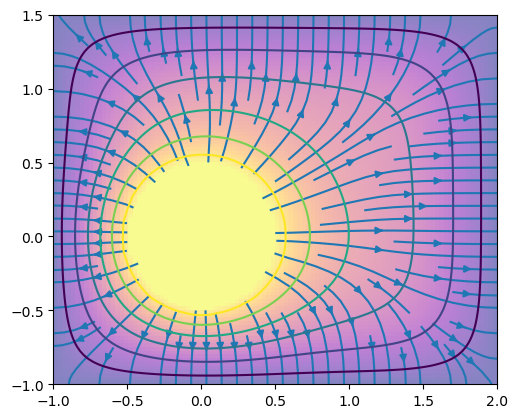

In [18]:
plt.imshow(V.transpose(),
           extent=(x[0],x[-1],y[0],y[-1]),
           origin='lower',
           cmap='plasma',alpha=0.5)
niveles = np.linspace(0.1,0.9,6)
plt.streamplot(x,y,Ey,Ex)
plt.contour(x,y,V.transpose(),levels=niveles)
plt.gca().set_aspect('equal')
plt.show()